In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

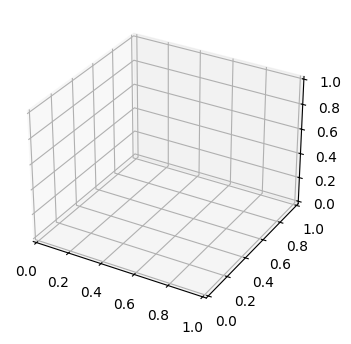

In [6]:
path = "Data/0820/corona_discharge_9.2kV_Eco_Oil/MLU#101_CH01_20250820090100.csv"
data = np.loadtxt(
    fname = path,
    delimiter = ","
    )
fig, ax = plt.subplots(figsize=(7, 4), subplot_kw={"projection": "3d"})

In [7]:
X = np.arange(0, 3600, 1)
Y = np.arange(0, 128, 1)
Z = data.T
X, Y = np.meshgrid(X, Y)

C:\Users\PC\AppData\Local\Temp\ipykernel_20536\2728790536.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(range(0, 360+1, 60), va='bottom')


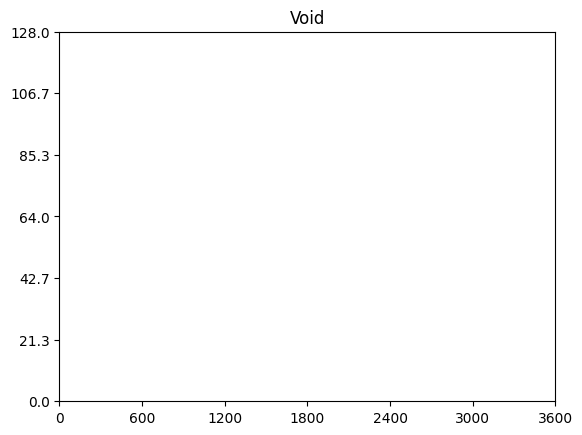

In [8]:
surf = ax.plot_surface(X, Y, Z, rstride = 1, cstride = 1, cmap = 'cool')
ax.set_zlim(0, 256)
plt.title("Void")

plt.xticks(np.arange(0, 3601, 600), rotation = 0)
plt.yticks(np.arange(0, 128+1, 128/6), rotation = 0)
ax.set_yticklabels(range(0, 360+1, 60), va='bottom')
ax.set_xlabel("Power cycle")
ax.set_ylabel("Phase")
ax.set_zlabel("Amplitude")

result = path.rsplit('/', 1)[0] + "/" + "PRPS_1_1_102_2024-04-02 15_32_00.csv".replace(".csv", "") + "2D.png"
plt.savefig(result, dpi= 350, format='png')
plt.show()

In [ ]:
d = data.flatten()

radio = np.linspace(0, 360, 128)

rows = np.array([radio for _ in range(3600)])
rows.shape

df = pd.DataFrame({"rows": rows.flatten(), "column": d})
df["map"] = df.apply(lambda x: f"{x[1]}, {x[0]}", axis=1)

b = df["column"] !=0
df = df[b]

count_df = df["map"].value_counts().reset_index()
count_df.columns = ["map", "count"]  # Explicitly set column names

df_join = pd.merge(df, count_df, left_on="map", right_on="map")

fig, ax = plt.subplots(figsize=(7, 4))

scatter = plt.scatter(df_join["rows"], df_join["column"],s=1.55, c=df_join["count"]*100, cmap='cool',alpha=1,vmin=0,vmax=3600)

plt.title("Void - 2D Phase-Amplitude")
plt.xticks(np.arange(0, 360+1, 60))
plt.yticks(np.arange(0, 255+1, 50))
plt.xlabel("Phase (°)")
plt.ylabel("Amplitude of PDs")

cbar = plt.colorbar(scatter, ticks=np.arange(0,3600+1,600))
cbar.set_label("Number of PDs")

result = path.rsplit('/', 1)[0] + "/" + "PRPS_1_1_102_2024-04-02 15_32_00.csv".replace(".csv", "") + "2D.png"
plt.savefig(result, dpi= 350, format='png')
    
plt.show()

KeyError: 1